# Chapter 9: Regression and Prediction


In this notebook, we explore simple and multiple linear regression.

We will study:

- scatterplots and regression lines
- slope and intercept
- prediction
- residuals
- prediction error
- R-squared
- overfitting
- training and testing data
- multiple regression
- regularization with Ridge and Lasso


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


## Simple Linear Regression


Simple linear regression uses one predictor variable to predict one response variable.

Here, we use temperature to predict electricity demand.


In [3]:
# Temperature and electricity demand example

temperature = np.array([
    2, 5, 7, 10, 12,
    15, 18, 20, 22,
    25, 27, 30, 32,
    35, 38
])

demand = np.array([
    230, 250, 265, 290, 310,
    330, 360, 370, 390,
    410, 430, 455, 470,
    495, 510
])


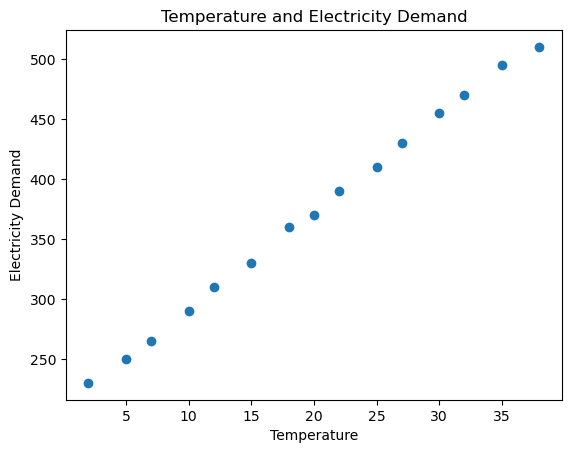

In [4]:
# Visualize the relationship

plt.scatter(temperature, demand)

plt.title("Temperature and Electricity Demand")

plt.xlabel("Temperature")
plt.ylabel("Electricity Demand")

plt.show()


In [5]:
# Reshape the predictor variable

X = temperature.reshape(-1, 1)

# Response variable

y = demand


In [6]:
# Create and train the regression model

model = LinearRegression()

model.fit(X, y)


LinearRegression()

In [7]:
# Intercept and slope

print("Intercept:", round(model.intercept_, 2))

print("Slope:", round(model.coef_[0], 2))


Intercept: 211.64
Slope: 8.02


In [8]:
# Predicted values

predictions = model.predict(X)


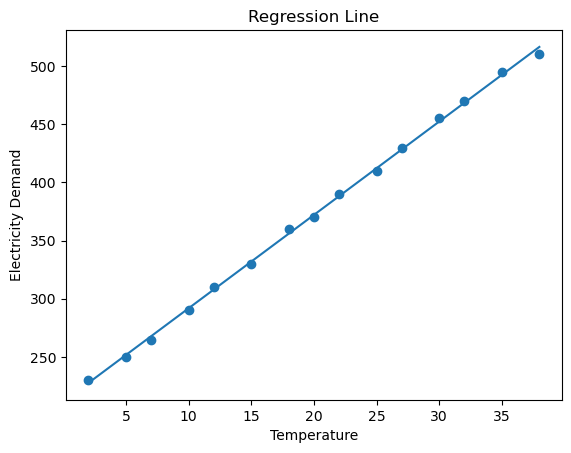

In [9]:
# Visualize the fitted regression line

plt.scatter(X, y)

plt.plot(X, predictions)

plt.title("Regression Line")

plt.xlabel("Temperature")
plt.ylabel("Electricity Demand")

plt.show()


## Making Predictions

In [10]:
# Predict electricity demand at 28 degrees

predicted_value = model.predict([[28]])

print("Predicted demand:", round(predicted_value[0], 2))


Predicted demand: 436.24


## Residuals

In [11]:
# Residuals measure prediction errors

residuals = y - predictions

print(residuals[:5])


[ 2.31572252 -1.74848462 -2.79128938 -1.85549652  2.10169872]


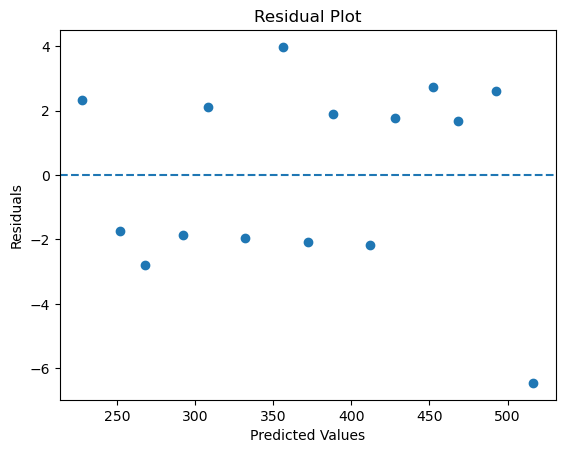

In [12]:
# Residual plot

plt.scatter(predictions, residuals)

plt.axhline(0, linestyle='--')

plt.title("Residual Plot")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")

plt.show()


## Measuring Prediction Error

In [13]:
# Mean Absolute Error

mae = mean_absolute_error(y, predictions)

print("MAE:", round(mae, 2))


MAE: 2.54


In [14]:
# Mean Squared Error

mse = mean_squared_error(y, predictions)

print("MSE:", round(mse, 2))


MSE: 7.87


In [15]:
# Root Mean Squared Error

rmse = np.sqrt(mse)

print("RMSE:", round(rmse, 2))


RMSE: 2.81


## R-Squared

In [16]:
# R-squared measures how much variability
# is explained by the model.

r_squared = r2_score(y, predictions)

print("R-squared:", round(r_squared, 3))


R-squared: 0.999


## Training and Testing Data


To check whether a model generalizes well, we split the data into:

- training data: used to fit the model
- testing data: used to evaluate the model on unseen data


In [17]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=1
)


In [18]:
# Train the model using only the training data

model = LinearRegression()

model.fit(X_train, y_train)


LinearRegression()

In [19]:
# Predictions on testing data

test_predictions = model.predict(X_test)


In [20]:
# Evaluate prediction error on testing data

test_rmse = np.sqrt(
    mean_squared_error(y_test, test_predictions)
)

print("Testing RMSE:", round(test_rmse, 2))


Testing RMSE: 2.86


# Multiple Linear Regression


Multiple linear regression uses several predictor variables at the same time.

Here, we use house size, bedrooms, and age to predict house price.


In [21]:
# House price example

house_data = pd.DataFrame({

    'size': [1200, 1500, 1800, 2000, 2300],
    'bedrooms': [2, 3, 3, 4, 4],
    'age': [20, 15, 12, 8, 5],
    'price': [250, 320, 360, 400, 460]

})

house_data


,size,bedrooms,age,price
0,1200,2,20,250
1,1500,3,15,320
2,1800,3,12,360
3,2000,4,8,400
4,2300,4,5,460


In [22]:
# Predictor variables

X = house_data[['size', 'bedrooms', 'age']]

# Response variable

y = house_data['price']


In [23]:
# Train the multiple regression model

model = LinearRegression()

model.fit(X, y)


LinearRegression()

In [24]:
# Regression coefficients

print("Intercept:", round(model.intercept_, 2))

print()

print("Coefficients:")

for name, coef in zip(X.columns, model.coef_):

    print(name + ":", round(coef, 2))


Intercept: 188.69

Coefficients:
size: 0.12
bedrooms: 2.17
age: -4.35


In [26]:
# New house information

new_house = pd.DataFrame({

    'size': [1900],
    'bedrooms': [3],
    'age': [10]

})

predicted_price = model.predict(new_house)


## Multicollinearity

In [27]:
# Correlation between predictor variables

print(X.corr())


              size  bedrooms       age
size      1.000000  0.935988 -0.994958
bedrooms  0.935988  1.000000 -0.966574
age      -0.994958 -0.966574  1.000000


## Feature Selection

In [28]:
# Sometimes simpler models perform better.

print("Good models balance simplicity and accuracy.")


Good models balance simplicity and accuracy.


# Appendix E: Regularization and Modern Predictive Modeling


Regularization helps control model complexity.

In this appendix, we will see how Ridge and Lasso regression behave differently from ordinary linear regression.


## Why Scaling Matters

In [29]:
# Variables on very different scales

scale_data = pd.DataFrame({

    'income': [40000, 50000, 60000, 70000],
    'age': [20, 25, 30, 35]

})

scale_data


,income,age
0,40000,20
1,50000,25
2,60000,30
3,70000,35


In [30]:
# Standardization gives a variable mean 0
# and standard deviation 1.

scaled_income = (
    scale_data['income'] - np.mean(scale_data['income'])
) / np.std(scale_data['income'])

print(scaled_income)


0   -1.341641
1   -0.447214
2    0.447214
3    1.341641
Name: income, dtype: float64


## Cyclical Variables

In [31]:
# Hours in a day

hours = np.array([0, 6, 12, 18, 23])


In [32]:
# Sine transformation

hour_sin = np.sin(2 * np.pi * hours / 24)

print(hour_sin)


[ 0.00000000e+00  1.00000000e+00  1.22464680e-16 -1.00000000e+00
 -2.58819045e-01]


In [33]:
# Cosine transformation

hour_cos = np.cos(2 * np.pi * hours / 24)

print(hour_cos)


[ 1.00000000e+00  6.12323400e-17 -1.00000000e+00 -1.83697020e-16
  9.65925826e-01]


## A Dataset for Regularization


To see the effect of Ridge and Lasso clearly, we create a dataset with:

- useful predictors
- correlated predictors
- one mostly useless predictor

This helps us see why regularization can be useful.


In [34]:
# House price dataset with one weak predictor

regularization_data = pd.DataFrame({

    'size': [1200, 1500, 1800, 2000, 2300, 2500, 2700, 3000],

    # Bedrooms is related to size
    'bedrooms': [2, 3, 3, 4, 4, 5, 5, 6],

    # Age is useful because newer houses tend to be more expensive
    'age': [20, 15, 12, 8, 5, 4, 3, 2],

    # This variable is mostly noise in this example
    'coffee_shops': [3, 8, 2, 7, 5, 1, 9, 4],

    'price': [250, 320, 360, 400, 460, 500, 540, 600]

})

regularization_data


,size,bedrooms,age,coffee_shops,price
0,1200,2,20,3,250
1,1500,3,15,8,320
2,1800,3,12,2,360
3,2000,4,8,7,400
4,2300,4,5,5,460
5,2500,5,4,1,500
6,2700,5,3,9,540
7,3000,6,2,4,600


In [35]:
# Predictor variables

X = regularization_data[
    ['size', 'bedrooms', 'age', 'coffee_shops']
]

# Response variable

y = regularization_data['price']


In [36]:
# Correlation between predictors

# Notice that size and bedrooms are highly related.
# This can make ordinary regression coefficients less stable.

print(X.corr())


                  size  bedrooms       age  coffee_shops
size          1.000000  0.978097 -0.970883      0.050179
bedrooms      0.978097  1.000000 -0.946235      0.075244
age          -0.970883 -0.946235  1.000000     -0.094402
coffee_shops  0.050179  0.075244 -0.094402      1.000000


## Scaling Before Regularization

In [37]:
# Ridge and Lasso are affected by the scale of variables.
# Therefore, we standardize the predictors first.

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)


## Ordinary Linear Regression

In [38]:
# Ordinary regression does not penalize large coefficients.

linear_model = LinearRegression()

linear_model.fit(X_scaled, y)


LinearRegression()

In [39]:
# Ordinary regression coefficients

print("Ordinary Linear Regression Coefficients")

print("Ordinary Linear Regression Coefficients")

print("size:",
      round(linear_model.coef_[0], 2))

print("bedrooms:",
      round(linear_model.coef_[1], 2))

print("age:",
      round(linear_model.coef_[2], 2))

print("coffee_shops:",
      round(linear_model.coef_[3], 2))


Ordinary Linear Regression Coefficients
Ordinary Linear Regression Coefficients
size: 107.36
bedrooms: 10.67
age: 8.1
coffee_shops: 2.35


## Ridge Regression

In [40]:
# Ridge regression shrinks coefficients toward zero.
# Larger alpha values apply stronger regularization.

ridge_model = Ridge(alpha=10)

ridge_model.fit(X_scaled, y)


Ridge(alpha=10)

In [41]:
# Ridge coefficients

print("Ridge Regression Coefficients")

for name, coef in zip(X.columns, ridge_model.coef_):

    print(name + ":", round(coef, 2))


Ridge Regression Coefficients
size: 26.94
bedrooms: 25.94
age: -24.74
coffee_shops: 0.95



Ridge usually keeps all predictors in the model, but it reduces the size of the coefficients.


## Lasso Regression

In [42]:
# Lasso regression can shrink some coefficients
# all the way to zero.

lasso_model = Lasso(alpha=10)

lasso_model.fit(X_scaled, y)


Lasso(alpha=10)

In [43]:
# Lasso coefficients

print("Lasso Regression Coefficients")

print("size:",
      round(lasso_model.coef_[0], 2))

print("bedrooms:",
      round(lasso_model.coef_[1], 2))

print("age:",
      round(lasso_model.coef_[2], 2))

print("coffee_shops:",
      round(lasso_model.coef_[3], 2))


Lasso Regression Coefficients
size: 92.75
bedrooms: 7.47
age: -0.0
coffee_shops: 0.0



Lasso may set weak predictor coefficients to zero.

This means Lasso can act as a simple feature-selection method.


## Comparing the Coefficients

In [44]:
# Put all coefficients into one table

comparison = pd.DataFrame({

    'Predictor': X.columns,

    'Ordinary Regression': linear_model.coef_,

    'Ridge Regression': ridge_model.coef_,

    'Lasso Regression': lasso_model.coef_

})

comparison


,Predictor,Ordinary Regression,Ridge Regression,Lasso Regression
0,size,107.355197,26.937965,92.749858
1,bedrooms,10.665459,25.936772,7.467474
2,age,8.095521,-24.738747,-0.000000
3,coffee_shops,2.350303,0.949724,0.000000


In [45]:
# Round the table for easier reading

comparison.round(2)


,Predictor,Ordinary Regression,Ridge Regression,Lasso Regression
0,size,107.36,26.94,92.75
1,bedrooms,10.67,25.94,7.47
2,age,8.10,-24.74,-0.00
3,coffee_shops,2.35,0.95,0.00



This table makes the difference easier to see:

- Ordinary regression freely estimates the coefficients.
- Ridge shrinks the coefficients but usually keeps all predictors.
- Lasso may shrink weak predictors to zero.


## Comparing Predictions

In [46]:
# Split the data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.3,
    random_state=1
)

In [47]:
# Compare predictions from the three models

# Ordinary linear regression

linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

ordinary_predictions = linear_model.predict(X_test)

# Ridge regression

ridge_model = Ridge(alpha=10)

ridge_model.fit(X_train, y_train)

ridge_predictions = ridge_model.predict(X_test)

# Lasso regression

lasso_model = Lasso(alpha=10)

lasso_model.fit(X_train, y_train)

lasso_predictions = lasso_model.predict(X_test)

In [48]:
# Compare testing RMSE values

ordinary_rmse = np.sqrt(
    mean_squared_error(y_test, ordinary_predictions)
)

ridge_rmse = np.sqrt(
    mean_squared_error(y_test, ridge_predictions)
)

lasso_rmse = np.sqrt(
    mean_squared_error(y_test, lasso_predictions)
)

print("Ordinary Regression RMSE:",
      round(ordinary_rmse, 2))

print("Ridge Regression RMSE:",
      round(ridge_rmse, 2))

print("Lasso Regression RMSE:",
      round(lasso_rmse, 2))


Ordinary Regression RMSE: 9.39
Ridge Regression RMSE: 62.27
Lasso Regression RMSE: 20.62



Regularized models may have slightly larger training error.

This is normal because they are intentionally making the model simpler.

The goal is not always to fit the training data perfectly, but to build a model that generalizes better to new data.


In [49]:
# In this small example, ordinary regression performs best.
# This can happen when the dataset is very small and the relationships are relatively clean.

# Ridge and Lasso become more useful when:
# - datasets are larger,
# - predictors are highly correlated,
# - many variables are included,
# - or overfitting becomes a serious problem.


print("Regularization is most helpful in more complex modeling situations.")

Regularization is most helpful in more complex modeling situations.
